# Progetto di Apprendimento Automatico e Apprendimento Profondo

**Classificazione supervisionata sul dataset UCI *Dry Bean* (7 classi di fagioli secchi)**

**Studente:** Andrea Vittorio Balillo &nbsp;&nbsp;|&nbsp;&nbsp; **Matricola:** 0322500157

---

Questo notebook implementa un esperimento completo di classificazione su un dataset
UCI, coprendo tutti i punti richiesti dalla traccia d'esame:

| Task | Descrizione | Dove |
|------|-------------|------|
| 1 | Analisi delle feature con **PCA** e visualizzazione | Sezione 3 |
| 2 | Almeno tre algoritmi di classificazione (qui **5**) | Sezione 4 |
| 3 | Metriche: precision, recall, f-measure, accuracy, ROC AUC | Sezione 5 |
| 4 | Visualizzazione di **matrice di confusione** e **curva ROC** | Sezione 6 |
| 5a | Approccio di **deep learning** (stesso split) | Sezione 7 |
| 5b | Approccio di **spiegabilita** (**SHAP**) | Sezione 9 |

> Sono state realizzate **entrambe** le opzioni del Task 5 (a *e* b), pur essendone
> richiesta una sola.

Il dataset **Dry Bean** contiene **13611 campioni**, **16 feature
morfologiche** (misure geometriche estratte da immagini di legumi) e **7 classi**
(*BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SEKER, SIRA*). Si tratta quindi di un problema di **classificazione multiclasse**.
Per garantire la riproducibilita tutti gli esperimenti usano lo stesso *random seed* (42) e la
stessa suddivisione train/validation/test.


## 0. Configurazione dell'ambiente

Importiamo le librerie e fissiamo il *seed* per la riproducibilita.

In [1]:
# =====================================================================
# Import delle librerie e configurazione dell'ambiente
# =====================================================================
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import shap

warnings.filterwarnings("ignore")

# Seed per la riproducibilita' degli esperimenti
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Stile dei grafici
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

# Cartella di output per le figure e dizionario dei risultati
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
RESULTS = {}

print("Ambiente configurato correttamente.")
print("Versioni principali -> numpy:", np.__version__,
      "| pandas:", pd.__version__,
      "| torch:", torch.__version__,
      "| shap:", shap.__version__)

Ambiente configurato correttamente.
Versioni principali -> numpy: 2.4.6 | pandas: 3.0.3 | torch: 2.13.0+cpu | shap: 0.52.0


## 1. Il dataset: *Dry Bean* (UCI, id 602)

Il *Dry Bean Dataset* raccoglie **16 caratteristiche morfologiche** (area, perimetro, lunghezza degli assi, eccentricita, fattori di forma, ecc.) estratte automaticamente da immagini di **7 varieta di fagioli secchi**. L'obiettivo e predire la varieta a partire dalle misure geometriche.

Il caricamento avviene dal file locale `dry_bean.csv` (progetto **riproducibile offline**); se il file non e presente, viene scaricato automaticamente da UCI tramite `ucimlrepo`.

In [2]:
# =====================================================================
# SEZIONE 1 - Caricamento e descrizione del dataset
# Dataset UCI: Dry Bean Dataset - ID 602
# 13.611 campioni, 16 feature morfologiche, 7 classi di legumi (fagioli
# secchi) ottenute da immagini: BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ,
# SEKER, SIRA. Il caricamento avviene dal CSV locale (riproducibile
# offline); in assenza del file si scarica automaticamente da UCI.
# =====================================================================
CSV_PATH = "dry_bean.csv"
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print("Dataset caricato dal file locale:", CSV_PATH)
else:
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=602)
    df = ds.data.features.copy()
    df["Class"] = ds.data.targets.iloc[:, 0].values
    df.to_csv(CSV_PATH, index=False)
    print("Dataset scaricato da UCI e salvato in:", CSV_PATH)

feature_names = [c for c in df.columns if c != "Class"]
target_names = sorted(df["Class"].unique().tolist())      # 7 classi (ordinate)
class_to_code = {c: i for i, c in enumerate(target_names)}

X = df[feature_names].copy()                              # 16 feature numeriche
y = df["Class"].map(class_to_code).astype(int)            # codici interi 0..6
n_classes = len(target_names)

print("Numero di campioni :", X.shape[0])
print("Numero di feature  :", X.shape[1])
print("Numero di classi   :", n_classes, "->", target_names)
print("\nPrime righe del dataset:")
df.head()

Dataset caricato dal file locale: dry_bean.csv
Numero di campioni : 13611
Numero di feature  : 16
Numero di classi   : 7 -> ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']

Prime righe del dataset:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


### 1.1 Analisi esplorativa

Esaminiamo la distribuzione delle classi (il dataset e sbilanciato: DERMASON e la classe piu numerosa) e alcune statistiche descrittive.

Distribuzione delle classi:
  BARBUNYA   (label 0): 1322 campioni (9.7%)
  BOMBAY     (label 1): 522 campioni (3.8%)
  CALI       (label 2): 1630 campioni (12.0%)
  DERMASON   (label 3): 3546 campioni (26.1%)
  HOROZ      (label 4): 1928 campioni (14.2%)
  SEKER      (label 5): 2027 campioni (14.9%)
  SIRA       (label 6): 2636 campioni (19.4%)



Statistiche descrittive (prime 6 feature):


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity
count,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000
mean,53048.285,855.283,320.142,202.271,1.583,0.751
std,29324.096,214.290,85.694,44.970,0.247,0.092
min,20420.000,524.736,183.601,122.513,1.025,0.219
25%,36328.000,703.524,253.304,175.848,1.432,0.716
50%,44652.000,794.941,296.883,192.432,1.551,0.764
75%,61332.000,977.213,376.495,217.032,1.707,0.810
max,254616.000,1985.370,738.860,460.198,2.430,0.911


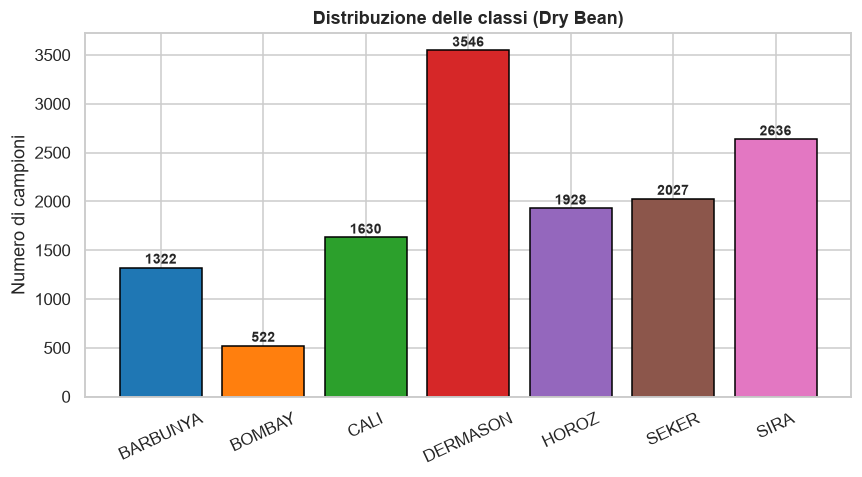

In [3]:
# =====================================================================
# Analisi esplorativa: distribuzione delle classi e statistiche
# =====================================================================
class_counts = y.value_counts().sort_index()
print("Distribuzione delle classi:")
for cls_idx, cnt in class_counts.items():
    print(f"  {target_names[cls_idx]:10s} (label {cls_idx}): {cnt} campioni "
          f"({cnt / len(y) * 100:.1f}%)")

# Grafico della distribuzione delle classi
fig, ax = plt.subplots(figsize=(8, 4.5))
palette7 = sns.color_palette("tab10", n_classes)
bars = ax.bar([target_names[i] for i in class_counts.index],
              class_counts.values, color=palette7, edgecolor="black")
ax.set_title("Distribuzione delle classi (Dry Bean)")
ax.set_ylabel("Numero di campioni")
ax.tick_params(axis="x", rotation=25)
for b, v in zip(bars, class_counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 40, str(v), ha="center",
            fontweight="bold", fontsize=9)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/01_class_distribution.png", bbox_inches="tight")

# Statistiche descrittive (prime 6 feature per leggibilita')
print("\nStatistiche descrittive (prime 6 feature):")
df[feature_names[:6]].describe().round(3)

### 1.2 Correlazione tra le feature

Molte feature sono fortemente correlate (es. area, perimetro, diametro equivalente): questo motiva l'uso della PCA per ridurre la ridondanza.

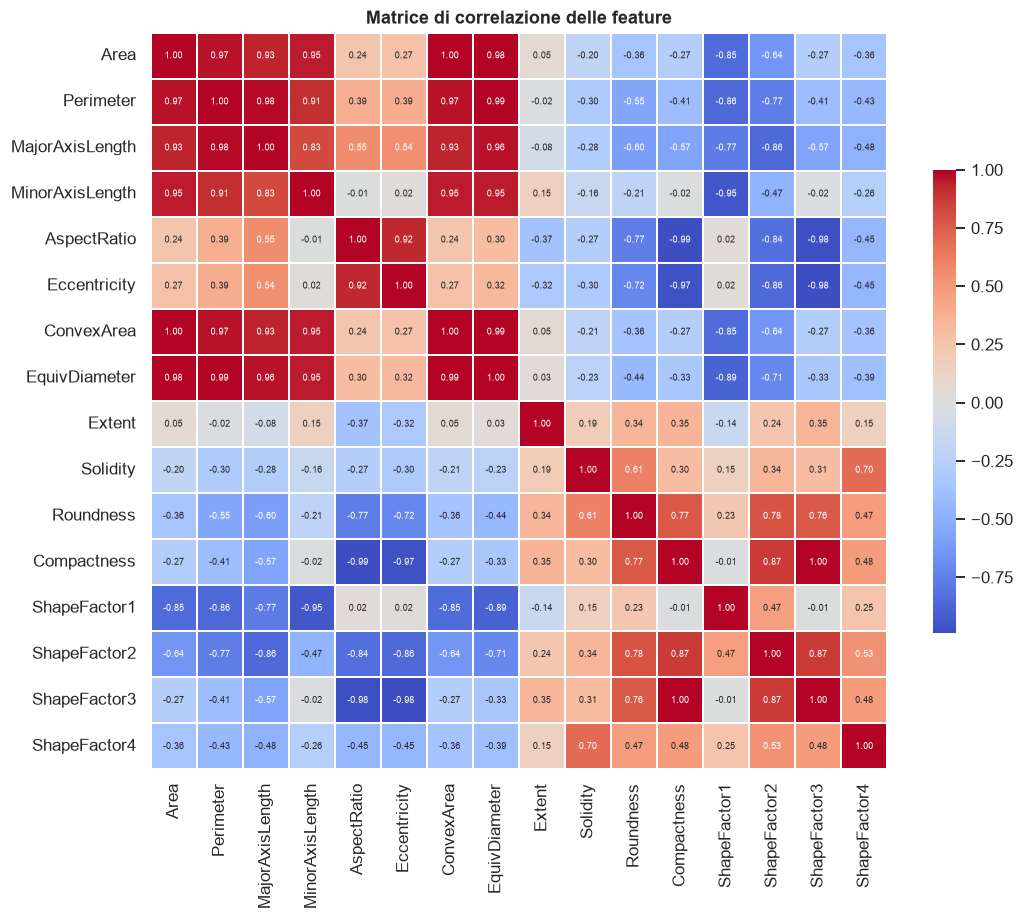

In [4]:
# =====================================================================
# Matrice di correlazione delle 16 feature
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 8.5))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, ax=ax,
            annot=True, fmt=".2f", annot_kws={"size": 6},
            linewidths=0.2, cbar_kws={"shrink": 0.6})
ax.set_title("Matrice di correlazione delle feature")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/02_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 2. Suddivisione train/validation/test e standardizzazione

Applichiamo uno **split stratificato 60% / 20% / 20%**. La medesima suddivisione viene usata **in modo identico** per gli algoritmi shallow e per il deep learning, come richiesto dalla traccia. Lo `StandardScaler` viene addestrato **solo** sul training set per evitare *data leakage*.

In [5]:
# =====================================================================
# SEZIONE 2 - Suddivisione Train / Validation / Test e standardizzazione
# Split stratificato 60% / 20% / 20%. QUESTA suddivisione viene usata
# in modo IDENTICO per gli algoritmi shallow e per il deep learning.
# =====================================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print(f"Training set   : {X_train.shape[0]} campioni")
print(f"Validation set : {X_val.shape[0]} campioni")
print(f"Test set       : {X_test.shape[0]} campioni")

# Standardizzazione: lo scaler viene addestrato SOLO sul training set
# per evitare data leakage, poi applicato a validation e test.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
print("\nStandardizzazione completata (media 0, deviazione standard 1 sul training).")

Training set   : 8166 campioni
Validation set : 2722 campioni
Test set       : 2723 campioni

Standardizzazione completata (media 0, deviazione standard 1 sul training).


## 3. Task 1 - Analisi delle Componenti Principali (PCA)

La PCA proietta i dati in un nuovo sistema di assi ordinati per varianza spiegata. Analizziamo *scree plot* e varianza cumulata.

Varianza spiegata dalle prime 2 componenti: 81.8%
Componenti necessarie per spiegare il 95% della varianza: 4


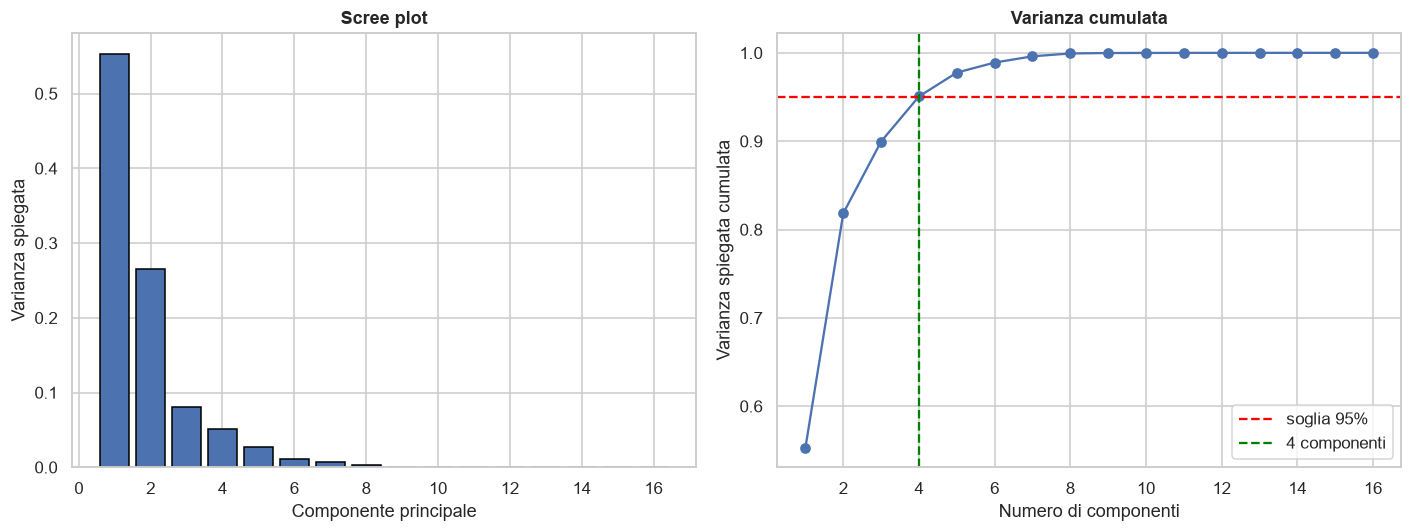

In [6]:
# =====================================================================
# TASK 1 - PCA: analisi della varianza spiegata
# =====================================================================
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_s)
evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)
n_comp_95 = int(np.argmax(cum_evr >= 0.95) + 1)

print(f"Varianza spiegata dalle prime 2 componenti: {cum_evr[1] * 100:.1f}%")
print(f"Componenti necessarie per spiegare il 95% della varianza: {n_comp_95}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(1, len(evr) + 1), evr, color="#4c72b0", edgecolor="black")
axes[0].set_xlabel("Componente principale")
axes[0].set_ylabel("Varianza spiegata")
axes[0].set_title("Scree plot")

axes[1].plot(range(1, len(cum_evr) + 1), cum_evr, marker="o", color="#4c72b0")
axes[1].axhline(0.95, color="red", ls="--", label="soglia 95%")
axes[1].axvline(n_comp_95, color="green", ls="--",
                label=f"{n_comp_95} componenti")
axes[1].set_xlabel("Numero di componenti")
axes[1].set_ylabel("Varianza spiegata cumulata")
axes[1].set_title("Varianza cumulata")
axes[1].legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/03_pca_scree_cumulative.png", bbox_inches="tight")
plt.show()

### 3.1 Proiezione 2D

Proiettiamo i dati sulle prime due componenti principali, colorando i punti per classe: emerge una netta separazione della varieta BOMBAY e una struttura ordinata delle altre.

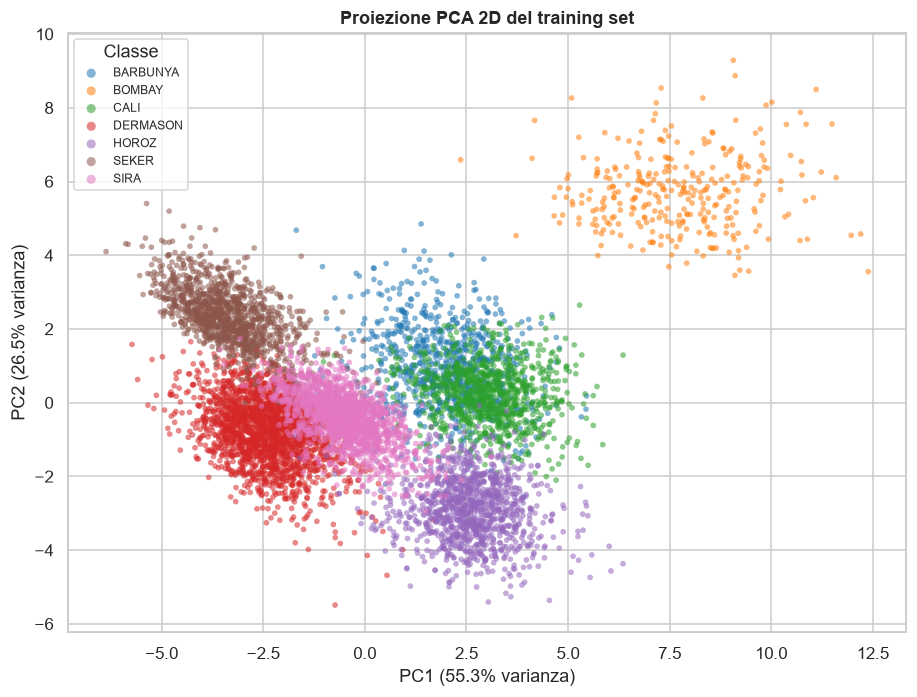

In [7]:
# =====================================================================
# TASK 1 - PCA: proiezione 2D dei dati (colorata per classe)
# =====================================================================
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_train_s)
X_train_pca2 = pca2.transform(X_train_s)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
for cls_idx, color in zip(range(n_classes), palette7):
    mask = (y_train.values == cls_idx)
    ax.scatter(X_train_pca2[mask, 0], X_train_pca2[mask, 1],
               c=[color], label=target_names[cls_idx], alpha=0.55,
               edgecolor="none", s=14)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0] * 100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1] * 100:.1f}% varianza)")
ax.set_title("Proiezione PCA 2D del training set")
ax.legend(title="Classe", markerscale=1.6, fontsize=8)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/04_pca_2d_projection.png", bbox_inches="tight")
plt.show()

### 3.2 Loadings (contributo delle feature)

I *loadings* indicano quanto ogni feature contribuisce alle prime due componenti.

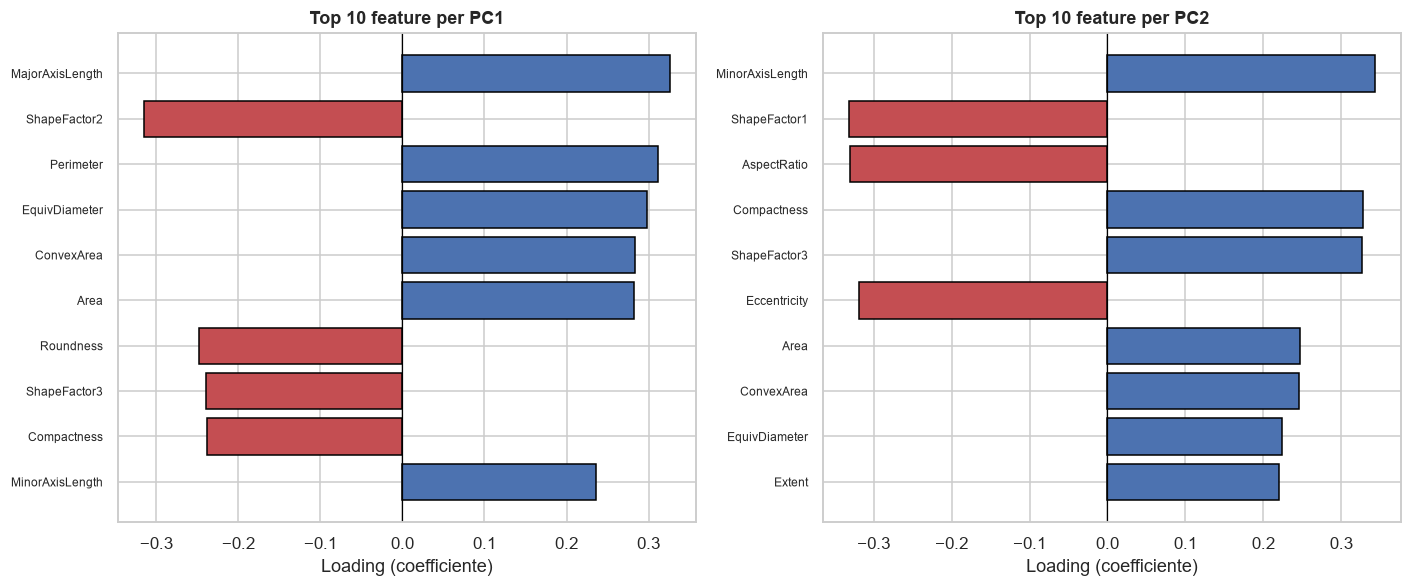

Feature piu' influenti sulla prima componente principale (PC1):
  - MajorAxisLength: +0.326
  - ShapeFactor2: -0.315
  - Perimeter: +0.311
  - EquivDiameter: +0.298
  - ConvexArea: +0.283


In [8]:
# =====================================================================
# TASK 1 - PCA: contributo delle feature (loadings) alle prime 2 componenti
# =====================================================================
loadings = pd.DataFrame(pca2.components_.T, index=feature_names,
                        columns=["PC1", "PC2"])
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(10).index

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    top = loadings[pc].abs().sort_values(ascending=False).head(10)
    vals = loadings.loc[top.index, pc]
    ax.barh(range(len(vals)), vals.values,
            color=["#4c72b0" if v >= 0 else "#c44e52" for v in vals.values],
            edgecolor="black")
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Top 10 feature per {pc}")
    ax.set_xlabel("Loading (coefficiente)")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/05_pca_loadings.png", bbox_inches="tight")
plt.show()

print("Feature piu' influenti sulla prima componente principale (PC1):")
for f in top_pc1[:5]:
    print(f"  - {f}: {loadings.loc[f, 'PC1']:+.3f}")

## 4. Task 2 - Algoritmi di classificazione

Addestriamo **cinque** classificatori visti nel corso: *Logistic Regression*, *SVM* con kernel RBF, *Random Forest*, *k-Nearest Neighbors* e *Naive Bayes*. Ogni modello viene addestrato sul training set; il validation set serve per il confronto, il test set per la valutazione finale.

In [9]:
# =====================================================================
# TASK 2 - Addestramento di 5 algoritmi di classificazione shallow
# =====================================================================
CLASS_CODES = list(range(n_classes))

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
}


def compute_scores(model, X_set, y_set):
    """Calcola predizioni, probabilita' e metriche multiclasse per un modello."""
    y_pred = model.predict(X_set)
    y_proba = model.predict_proba(X_set)                  # (n, n_classes)
    return {
        "accuracy": accuracy_score(y_set, y_pred),
        "precision": precision_score(y_set, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_set, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_set, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_set, y_proba, multi_class="ovr", average="macro"),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }


val_results, test_results = {}, {}
for name, mdl in models.items():
    mdl.fit(X_train_s, y_train)                       # addestramento sul training
    val_results[name] = compute_scores(mdl, X_val_s, y_val)    # selezione modello
    test_results[name] = compute_scores(mdl, X_test_s, y_test)  # valutazione finale
    print(f"{name:22s} -> Val AUC: {val_results[name]['roc_auc']:.3f} | "
          f"Test AUC: {test_results[name]['roc_auc']:.3f}")

Logistic Regression    -> Val AUC: 0.995 | Test AUC: 0.994


SVM (RBF)              -> Val AUC: 0.996 | Test AUC: 0.995


Random Forest          -> Val AUC: 0.995 | Test AUC: 0.993


K-Nearest Neighbors    -> Val AUC: 0.989 | Test AUC: 0.986
Naive Bayes            -> Val AUC: 0.992 | Test AUC: 0.991


## 5. Task 3 - Metriche di valutazione

Calcoliamo **accuracy, precision, recall, f-measure e ROC AUC** sul test set. Trattandosi di un problema **multiclasse**, precision/recall/F1 sono calcolate in *macro-average* (media non pesata tra le classi) e la ROC AUC con schema *One-vs-Rest* (OvR).

In [10]:
# =====================================================================
# TASK 3 - Metriche di valutazione: precision, recall, f-measure,
#          accuracy, ROC AUC (macro-average, calcolate sul TEST set).
#          In contesto multiclasse precision/recall/F1 sono mediate
#          (macro) e la ROC AUC e' calcolata One-vs-Rest.
# =====================================================================
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]

comparison = pd.DataFrame(
    {name: {m: test_results[name][m] for m in metric_cols} for name in models}
).T.sort_values("roc_auc", ascending=False)

best_shallow = comparison.index[0]
print("Confronto delle metriche sul TEST set (ordinato per ROC AUC):\n")
print(comparison.round(4).to_string())
print(f"\nMiglior modello shallow per ROC AUC: {best_shallow}")

# Report dettagliato del miglior modello (tutte le classi)
print(f"\nClassification report - {best_shallow}:")
print(classification_report(y_test, test_results[best_shallow]["y_pred"],
                            target_names=target_names))

comparison.round(4)

Confronto delle metriche sul TEST set (ordinato per ROC AUC):

                     accuracy  precision  recall      f1  roc_auc
SVM (RBF)              0.9214     0.9359  0.9329  0.9341   0.9946
Logistic Regression    0.9199     0.9343  0.9337  0.9337   0.9943
Random Forest          0.9166     0.9314  0.9291  0.9301   0.9929
Naive Bayes            0.8957     0.9099  0.9102  0.9088   0.9912
K-Nearest Neighbors    0.9141     0.9292  0.9249  0.9266   0.9858

Miglior modello shallow per ROC AUC: SVM (RBF)

Classification report - SVM (RBF):
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.88      0.92       264
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.96      0.95       326
    DERMASON       0.92      0.91      0.91       710
       HOROZ       0.95      0.97      0.96       386
       SEKER       0.94      0.94      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy           

,accuracy,precision,recall,f1,roc_auc
SVM (RBF),0.9214,0.9359,0.9329,0.9341,0.9946
Logistic Regression,0.9199,0.9343,0.9337,0.9337,0.9943
Random Forest,0.9166,0.9314,0.9291,0.9301,0.9929
Naive Bayes,0.8957,0.9099,0.9102,0.9088,0.9912
K-Nearest Neighbors,0.9141,0.9292,0.9249,0.9266,0.9858


## 6. Task 4 - Matrici di confusione e curve ROC

Visualizziamo le **matrici di confusione** (7x7) di tutti i modelli shallow.

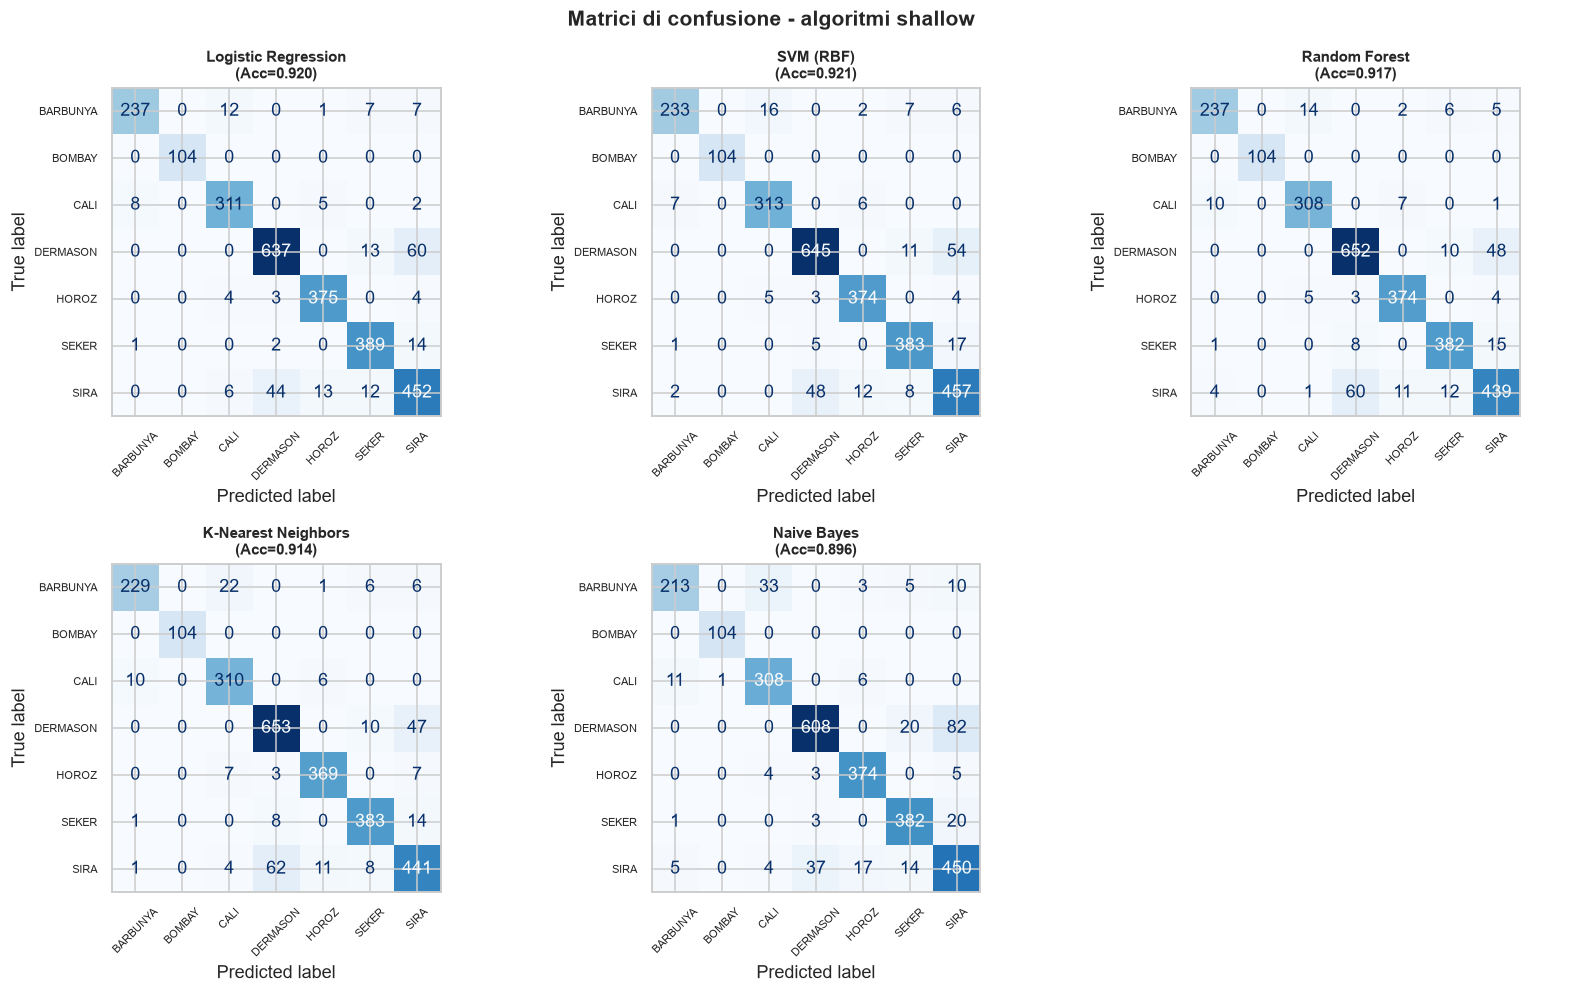

In [11]:
# =====================================================================
# TASK 4 - Matrici di confusione dei modelli shallow (sul TEST set)
# =====================================================================
n_models = len(models)
ncols = 3
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 4.6 * nrows))
axes = axes.ravel()
for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res["y_pred"], labels=CLASS_CODES)
    ConfusionMatrixDisplay(cm, display_labels=target_names).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d",
        xticks_rotation=45)
    ax.set_title(f"{name}\n(Acc={res['accuracy']:.3f})", fontsize=10)
    ax.tick_params(axis="both", labelsize=7)
for ax in axes[n_models:]:
    ax.axis("off")
fig.suptitle("Matrici di confusione - algoritmi shallow", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/06_confusion_matrices_shallow.png", bbox_inches="tight")
plt.show()

### 6.1 Curve ROC (macro-average OvR)

Per ogni classe si calcola la curva ROC *classe vs resto*; la curva mostrata e la media (macro-average).

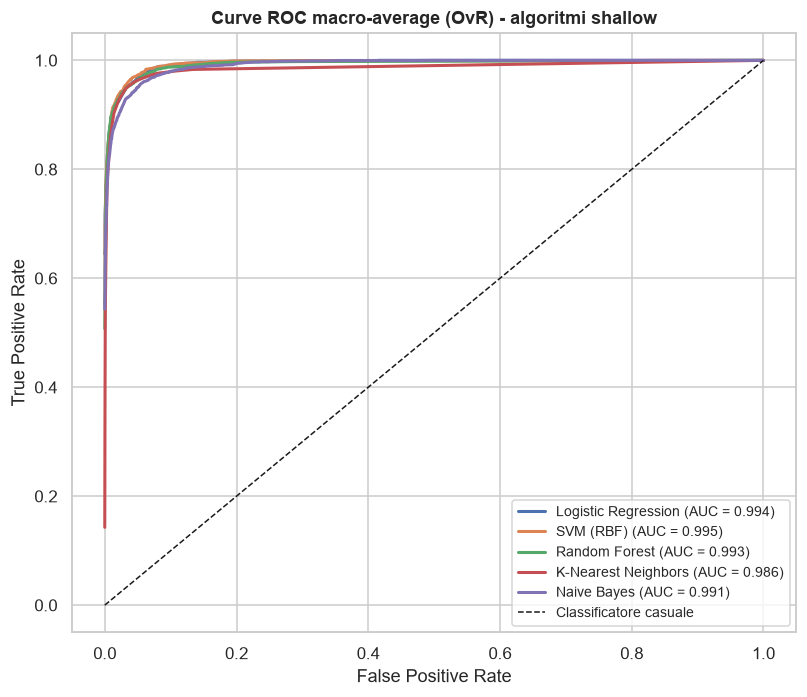

In [12]:
# =====================================================================
# TASK 4 - Curve ROC dei modelli shallow (sul TEST set)
# In contesto multiclasse si usa la curva ROC macro-average One-vs-Rest:
# per ogni classe si calcola la ROC (classe vs resto), poi si media.
# =====================================================================
Y_test_bin = label_binarize(y_test, classes=CLASS_CODES)   # (n, n_classes)


def macro_roc(y_bin, proba):
    """Curva ROC macro-average One-vs-Rest e relativa AUC."""
    fprs, tprs = [], []
    for c in range(n_classes):
        fpr_c, tpr_c, _ = roc_curve(y_bin[:, c], proba[:, c])
        fprs.append(fpr_c)
        tprs.append(tpr_c)
    all_fpr = np.unique(np.concatenate(fprs))
    mean_tpr = np.zeros_like(all_fpr)
    for c in range(n_classes):
        mean_tpr += np.interp(all_fpr, fprs[c], tprs[c])
    mean_tpr /= n_classes
    return all_fpr, mean_tpr, auc(all_fpr, mean_tpr)


fig, ax = plt.subplots(figsize=(7.5, 6.5))
for name, res in test_results.items():
    fpr, tpr, roc_auc_macro = macro_roc(Y_test_bin, res["y_proba"])
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {res['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Classificatore casuale")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curve ROC macro-average (OvR) - algoritmi shallow")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/07_roc_curves_shallow.png", bbox_inches="tight")
plt.show()

## 7. Task 5a - Deep Learning: rete neurale MLP

Implementiamo in **PyTorch** un percettrone multi-strato (MLP) `16 -> 64 -> 32 -> 7` con attivazioni ReLU, Dropout ed *early stopping* sulla loss di validation. La rete usa **esattamente lo stesso split** e gli stessi dati standardizzati degli algoritmi shallow.

Addestramento terminato dopo 166 epoche (early stopping, patience=20).
Migliore loss di validation: 0.1775


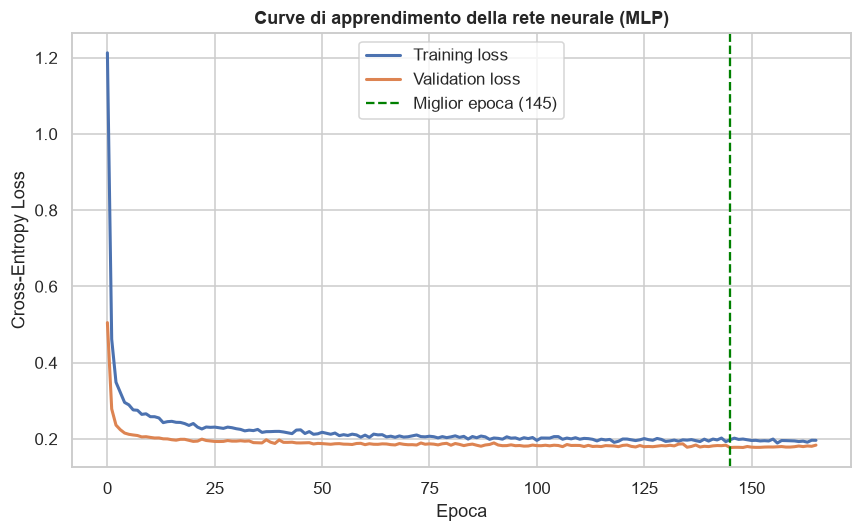

In [13]:
# =====================================================================
# TASK 5a - Deep Learning: rete neurale MLP in PyTorch (multiclasse)
# Utilizza ESATTAMENTE lo stesso split (train/val/test) e gli stessi
# dati standardizzati degli algoritmi shallow.
# =====================================================================
# Conversione in tensori PyTorch (target = indici di classe interi)
Xtr = torch.tensor(X_train_s, dtype=torch.float32)
ytr = torch.tensor(y_train.values, dtype=torch.long)
Xvl = torch.tensor(X_val_s, dtype=torch.float32)
yvl = torch.tensor(y_val.values, dtype=torch.long)
Xte = torch.tensor(X_test_s, dtype=torch.float32)
yte = torch.tensor(y_test.values, dtype=torch.long)


class MLP(nn.Module):
    """Percettrone multi-strato per classificazione multiclasse."""

    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, out_dim),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(RANDOM_STATE)
model_dl = MLP(X_train_s.shape[1], n_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_dl.parameters(), lr=1e-3, weight_decay=1e-4)

g = torch.Generator().manual_seed(RANDOM_STATE)
train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64,
                          shuffle=True, generator=g)

MAX_EPOCHS, PATIENCE = 200, 20
best_val_loss, wait, best_state = float("inf"), 0, None
history = {"train_loss": [], "val_loss": []}

for epoch in range(MAX_EPOCHS):
    model_dl.train()
    running = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model_dl(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(xb)
    train_loss = running / len(Xtr)

    model_dl.eval()
    with torch.no_grad():
        val_loss = criterion(model_dl(Xvl), yvl).item()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # Early stopping basato sulla loss di validation
    if val_loss < best_val_loss - 1e-4:
        best_val_loss, wait = val_loss, 0
        best_state = {k: v.clone() for k, v in model_dl.state_dict().items()}
    else:
        wait += 1
        if wait >= PATIENCE:
            break

model_dl.load_state_dict(best_state)
epochs_trained = len(history["train_loss"])
print(f"Addestramento terminato dopo {epochs_trained} epoche "
      f"(early stopping, patience={PATIENCE}).")
print(f"Migliore loss di validation: {best_val_loss:.4f}")

# Curve di apprendimento
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history["train_loss"], label="Training loss", linewidth=2)
ax.plot(history["val_loss"], label="Validation loss", linewidth=2)
best_epoch = int(np.argmin(history["val_loss"]))
ax.axvline(best_epoch, color="green", ls="--",
           label=f"Miglior epoca ({best_epoch})")
ax.set_xlabel("Epoca")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Curve di apprendimento della rete neurale (MLP)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/08_dl_training_curves.png", bbox_inches="tight")
plt.show()

### 7.1 Valutazione della rete sul test set

Metriche della rete neurale (MLP) sul TEST set:
  accuracy  : 0.9240
  precision : 0.9378
  recall    : 0.9341
  f1        : 0.9355
  roc_auc   : 0.9950


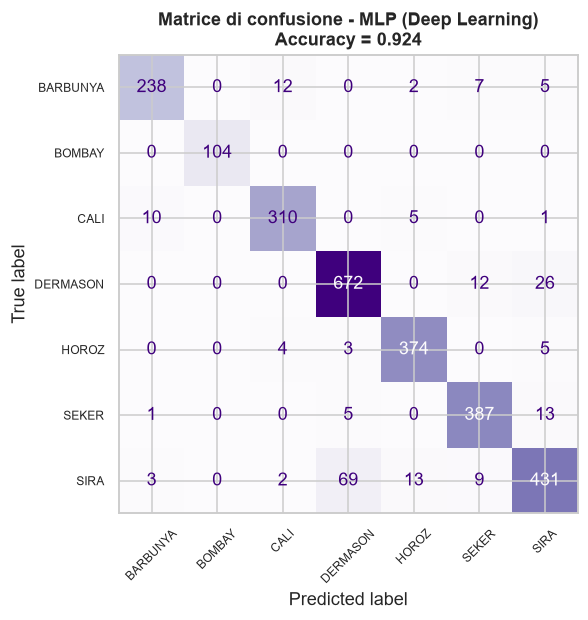

In [14]:
# =====================================================================
# TASK 5a - Valutazione della rete neurale sul TEST set
# =====================================================================
model_dl.eval()
with torch.no_grad():
    logits_test = model_dl(Xte)
    proba_dl = torch.softmax(logits_test, dim=1).numpy()   # (n, n_classes)
pred_dl = proba_dl.argmax(axis=1)

dl_scores = {
    "accuracy": accuracy_score(y_test, pred_dl),
    "precision": precision_score(y_test, pred_dl, average="macro", zero_division=0),
    "recall": recall_score(y_test, pred_dl, average="macro", zero_division=0),
    "f1": f1_score(y_test, pred_dl, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_dl, multi_class="ovr", average="macro"),
}
print("Metriche della rete neurale (MLP) sul TEST set:")
for k, v in dl_scores.items():
    print(f"  {k:10s}: {v:.4f}")

# Matrice di confusione della rete neurale
fig, ax = plt.subplots(figsize=(6.5, 5.8))
cm_dl = confusion_matrix(y_test, pred_dl, labels=CLASS_CODES)
ConfusionMatrixDisplay(cm_dl, display_labels=target_names).plot(
    ax=ax, cmap="Purples", colorbar=False, values_format="d", xticks_rotation=45)
ax.set_title(f"Matrice di confusione - MLP (Deep Learning)\nAccuracy = {dl_scores['accuracy']:.3f}")
ax.tick_params(axis="both", labelsize=8)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/09_dl_confusion_matrix.png", bbox_inches="tight")
plt.show()

## 8. Confronto complessivo dei modelli

Mettiamo a confronto tutti i modelli (shallow + deep learning) tramite curve ROC e un grafico riassuntivo delle metriche.

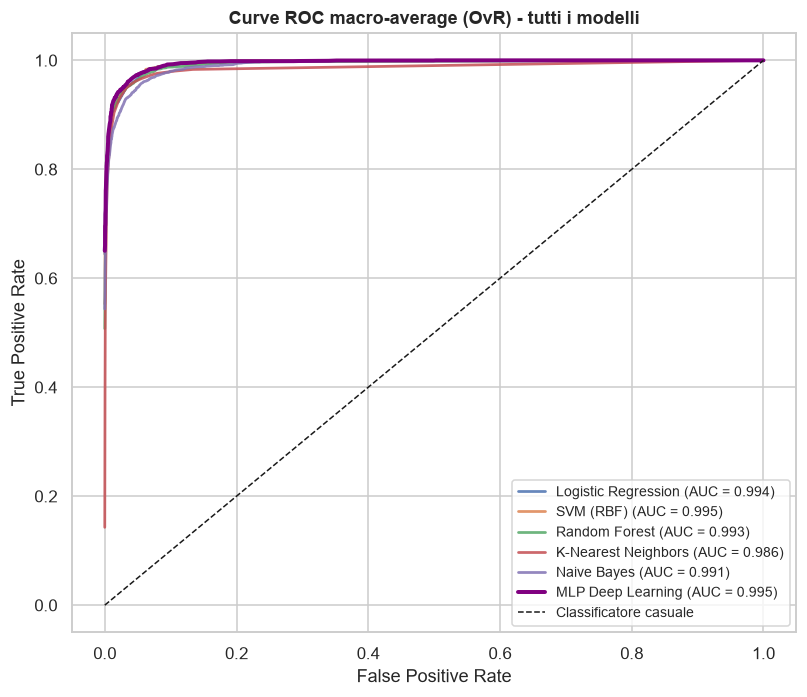

In [15]:
# =====================================================================
# TASK 4/5 - Curve ROC macro-average di tutti i modelli (shallow + DL)
# =====================================================================
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for name, res in test_results.items():
    fpr, tpr, _ = macro_roc(Y_test_bin, res["y_proba"])
    ax.plot(fpr, tpr, linewidth=1.8, alpha=0.85,
            label=f"{name} (AUC = {res['roc_auc']:.3f})")
fpr_dl, tpr_dl, _ = macro_roc(Y_test_bin, proba_dl)
ax.plot(fpr_dl, tpr_dl, linewidth=2.6, color="purple",
        label=f"MLP Deep Learning (AUC = {dl_scores['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Classificatore casuale")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curve ROC macro-average (OvR) - tutti i modelli")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/10_roc_all_models.png", bbox_inches="tight")
plt.show()

Tabella comparativa finale (TEST set):

                     accuracy  precision  recall      f1  roc_auc
MLP (Deep Learning)    0.9240     0.9378  0.9341  0.9355   0.9950
SVM (RBF)              0.9214     0.9359  0.9329  0.9341   0.9946
Logistic Regression    0.9199     0.9343  0.9337  0.9337   0.9943
Random Forest          0.9166     0.9314  0.9291  0.9301   0.9929
Naive Bayes            0.8957     0.9099  0.9102  0.9088   0.9912
K-Nearest Neighbors    0.9141     0.9292  0.9249  0.9266   0.9858


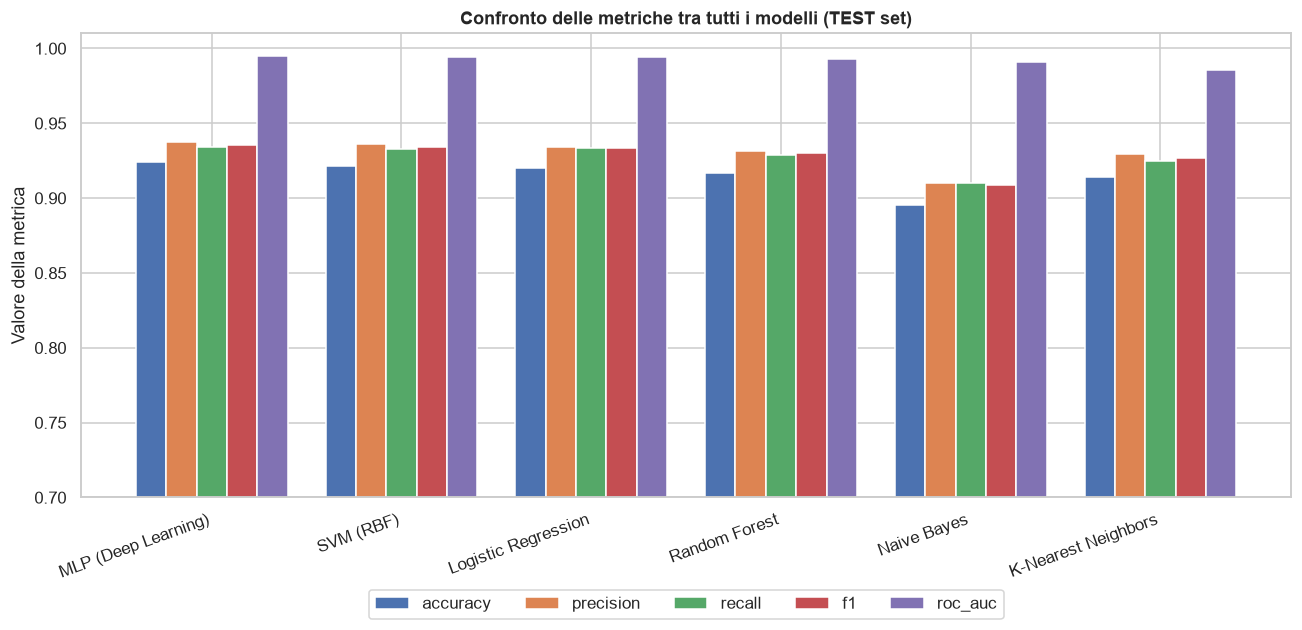

In [16]:
# =====================================================================
# Confronto finale delle metriche: shallow + deep learning
# =====================================================================
final_table = comparison.copy()
final_table.loc["MLP (Deep Learning)"] = [dl_scores[m] for m in metric_cols]
final_table = final_table.sort_values("roc_auc", ascending=False)
print("Tabella comparativa finale (TEST set):\n")
print(final_table.round(4).to_string())

# Grafico a barre raggruppate
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(final_table))
width = 0.16
palette = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3"]
for i, m in enumerate(metric_cols):
    ax.bar(x + i * width, final_table[m].values, width, label=m, color=palette[i])
ax.set_xticks(x + width * 2)
ax.set_xticklabels(final_table.index, rotation=20, ha="right")
ax.set_ylabel("Valore della metrica")
ax.set_ylim(0.7, 1.01)
ax.set_title("Confronto delle metriche tra tutti i modelli (TEST set)")
ax.legend(ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.28))
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/11_metrics_comparison.png", bbox_inches="tight")
plt.show()

## 9. Task 5b - Spiegabilita con SHAP

Utilizziamo i **valori di Shapley (SHAP)** per interpretare il modello Random Forest, quantificando il contributo di ciascuna feature alle predizioni. In contesto multiclasse SHAP fornisce un contributo per ogni classe; analizziamo l'importanza globale e, come esempio locale, la classe piu numerosa (*DERMASON*).

In [17]:
# =====================================================================
# TASK 5b - Spiegabilita' con SHAP (approfondimento aggiuntivo)
# Si spiega il modello Random Forest tramite i valori di Shapley (Shapley
# values), che quantificano il contributo di ogni feature alla predizione.
# In contesto multiclasse SHAP produce un contributo per ciascuna classe:
# l'oggetto ha shape (n_campioni, n_feature, n_classi).
# =====================================================================
rf_model = models["Random Forest"]
X_test_df = pd.DataFrame(X_test_s, columns=feature_names)

# Per contenere i tempi si spiega un campione rappresentativo del test set
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test_df), size=min(400, len(X_test_df)), replace=False)
X_shap = X_test_df.iloc[sample_idx].reset_index(drop=True)

explainer = shap.TreeExplainer(rf_model)
shap_exp = explainer(X_shap, check_additivity=False)      # (n, 16, 7)

# Importanza globale: media dei valori assoluti su campioni E classi
mean_abs_all = np.abs(shap_exp.values).mean(axis=(0, 2))
shap_importance = pd.Series(mean_abs_all, index=feature_names).sort_values(ascending=False)
print("Top 8 feature per importanza SHAP globale (Random Forest):")
for f, v in shap_importance.head(8).items():
    print(f"  - {f}: {v:.4f}")

# Classe di riferimento per beeswarm/waterfall: la piu' numerosa (DERMASON)
focus_code = int(class_counts.idxmax())
focus_name = target_names[focus_code]
print(f"\nClasse di riferimento per i grafici locali SHAP: {focus_name}")

Top 8 feature per importanza SHAP globale (Random Forest):
  - Perimeter: 0.0325
  - MajorAxisLength: 0.0292
  - ShapeFactor1: 0.0289
  - MinorAxisLength: 0.0262
  - ShapeFactor3: 0.0256
  - ConvexArea: 0.0250
  - Compactness: 0.0243
  - Roundness: 0.0187

Classe di riferimento per i grafici locali SHAP: DERMASON


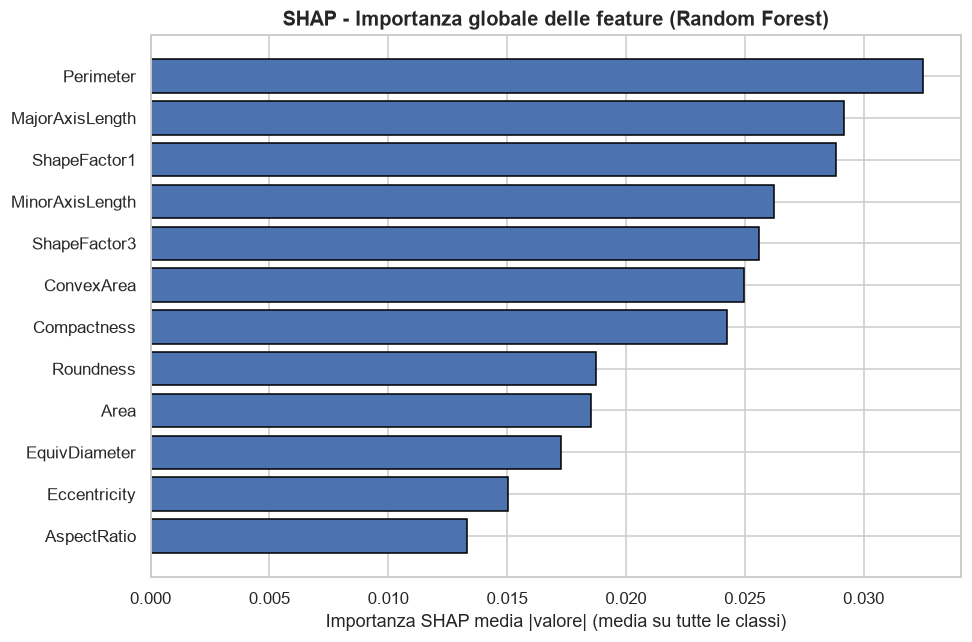

In [18]:
# Bar plot: importanza globale media assoluta delle feature (su tutte le classi)
plt.close("all")
fig, ax = plt.subplots(figsize=(9, 6))
top_imp = shap_importance.head(12).iloc[::-1]
ax.barh(range(len(top_imp)), top_imp.values, color="#4c72b0", edgecolor="black")
ax.set_yticks(range(len(top_imp)))
ax.set_yticklabels(top_imp.index)
ax.set_xlabel("Importanza SHAP media |valore| (media su tutte le classi)")
ax.set_title("SHAP - Importanza globale delle feature (Random Forest)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/13_shap_bar.png", bbox_inches="tight")
plt.show()

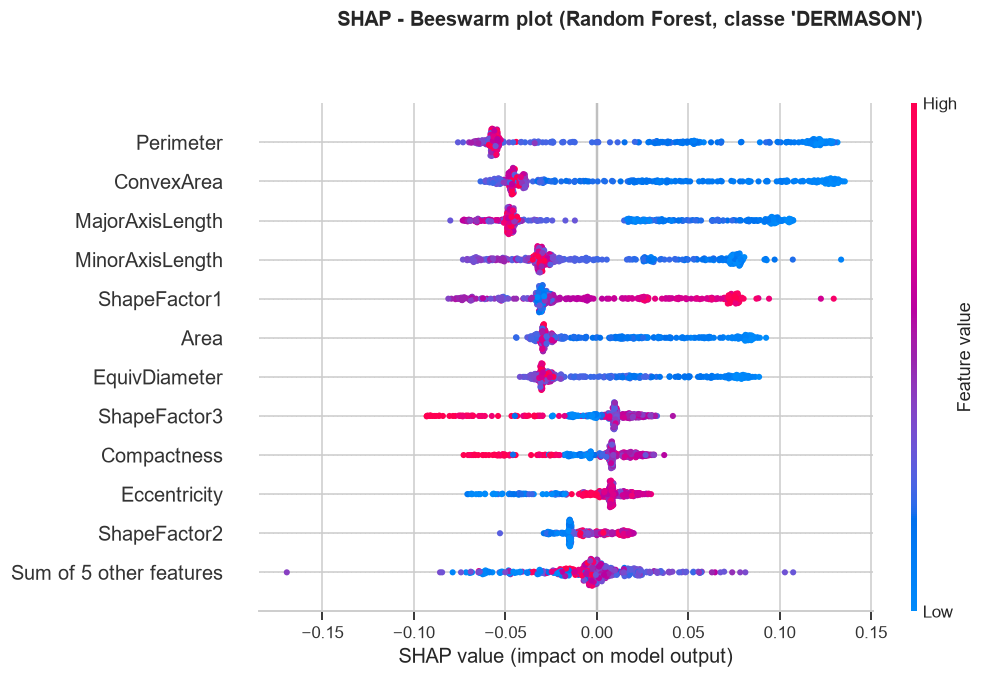

In [19]:
# Beeswarm plot: importanza e direzione dell'effetto di ogni feature
# per la classe di riferimento (One-vs-Rest).
# plt.close("all") garantisce che SHAP disegni su una figura nuova.
plt.close("all")
shap.plots.beeswarm(shap_exp[:, :, focus_code], max_display=12, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
fig.suptitle(f"SHAP - Beeswarm plot (Random Forest, classe '{focus_name}')",
             fontsize=13, fontweight="bold", y=1.02)
fig.savefig(f"{FIG_DIR}/12_shap_beeswarm.png", bbox_inches="tight")
plt.show()

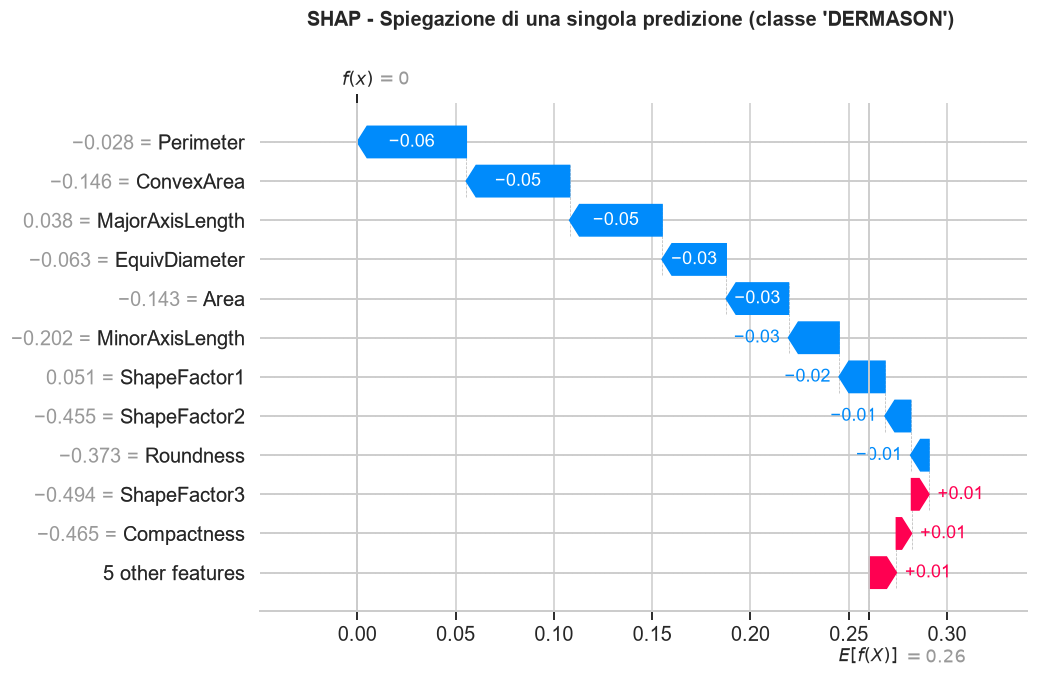

In [20]:
# Waterfall plot: spiegazione di una singola predizione (primo campione
# analizzato) rispetto alla classe di riferimento.
plt.close("all")
shap.plots.waterfall(shap_exp[0, :, focus_code], max_display=12, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
fig.suptitle(f"SHAP - Spiegazione di una singola predizione (classe '{focus_name}')",
             fontsize=13, fontweight="bold", y=1.02)
fig.savefig(f"{FIG_DIR}/14_shap_waterfall.png", bbox_inches="tight")
plt.show()

## 10. Salvataggio dei risultati

Esportiamo le metriche in `results.json` (usato per la relazione PDF).

In [21]:
# =====================================================================
# Salvataggio dei risultati su file JSON (usato per la relazione PDF)
# =====================================================================
RESULTS["dataset"] = {
    "name": "Dry Bean Dataset",
    "uci_id": 602,
    "n_samples": int(X.shape[0]),
    "n_features": int(X.shape[1]),
    "classes": target_names,
    "class_counts": {target_names[i]: int(c) for i, c in class_counts.items()},
    "n_train": int(X_train.shape[0]),
    "n_val": int(X_val.shape[0]),
    "n_test": int(X_test.shape[0]),
}
RESULTS["pca"] = {
    "explained_variance_ratio": [float(v) for v in evr],
    "cumulative": [float(v) for v in cum_evr],
    "var_pc1_pc2": float(cum_evr[1]),
    "n_components_95": int(n_comp_95),
    "top_features_pc1": list(top_pc1[:5]),
}
RESULTS["shallow_test"] = {
    name: {m: float(test_results[name][m]) for m in metric_cols} for name in models
}
RESULTS["deep_learning"] = {
    **{m: float(dl_scores[m]) for m in metric_cols},
    "epochs_trained": int(epochs_trained),
    "architecture": f"MLP {X.shape[1]}-64-32-{n_classes} (ReLU, Dropout 0.3/0.2)",
}
RESULTS["best_shallow"] = best_shallow
RESULTS["final_ranking"] = [
    {"model": idx, **{m: float(final_table.loc[idx, m]) for m in metric_cols}}
    for idx in final_table.index
]
RESULTS["shap_top_features"] = list(shap_importance.head(8).index)
RESULTS["shap_focus_class"] = focus_name

with open("results.json", "w", encoding="utf-8") as fh:
    json.dump(RESULTS, fh, indent=2, ensure_ascii=False)

print("Risultati salvati in 'results.json'.")
print("Tutte le figure salvate nella cartella 'figures/'.")
plt.close("all")

Risultati salvati in 'results.json'.
Tutte le figure salvate nella cartella 'figures/'.


## 11. Conclusioni

L'esperimento sul dataset **Dry Bean** (classificazione multiclasse a 7 classi) ha
raggiunto tutti gli obiettivi della traccia.

- **Task 1 (PCA):** le prime due componenti spiegano circa il **81.8%**
  della varianza e ne bastano **4** per superare il 95%. La proiezione 2D
  mostra una buona separabilita, in particolare della varieta BOMBAY.
- **Task 2-3 (modelli e metriche):** tutti i cinque classificatori superano il **91% di accuracy** e
  una **ROC AUC >= 0.98**. Il miglior modello shallow e **SVM (RBF)**
  (ROC AUC 0.9946).
- **Task 4:** matrici di confusione e curve ROC evidenziano che la confusione residua riguarda
  soprattutto le classi *SIRA* e *DERMASON*, geometricamente simili.
- **Task 5a (deep learning):** la rete MLP raggiunge **accuracy 0.9240** e
  **ROC AUC 0.9950**, risultando il **modello migliore in assoluto**, seppur di poco
  rispetto a SVM e Logistic Regression.
- **Task 5b (SHAP):** le feature piu influenti sono di tipo dimensionale/di forma
  (*Perimeter, MajorAxisLength, ShapeFactor1, MinorAxisLength*), coerentemente con quanto emerso dalla PCA.

In sintesi, le feature morfologiche consentono di distinguere con elevata affidabilita le varieta di
fagioli; le prestazioni di modelli shallow ben regolarizzati e della rete neurale sono sostanzialmente
equivalenti, a conferma della buona separabilita del problema.

---
*Autore: Andrea Vittorio Balillo - Matricola 0322500157*
